

Columns Description

* UserID: Unique identifier assigned to each user.
* Age: The user's age. - Gender: The user's gender (e.g., male, female, non-binary).
* Location: Geographic location of the user.
* Income: The user's income level.
* Debt: Amount of debt the user has.
* Owns Property: Indicates whether the user owns property.
* Profession: The user's occupation or job.
* Demographics: Statistical data about the user (e.g., age, gender, income).
* Platform: The platform the user is using (e.g., website, mobile app).
* Total Time Spent: The total time the user spends on the platform.
* Number of Sessions: The number of times the user has logged into the platform.
* Video ID: Unique identifier for a video.
* Video Category: The category or genre of the video.
* Video Length: Duration of the video.
* Engagement: User interaction with the video (e.g., likes, comments, shares).
* Importance Score: A score indicating how important the video is to the user.
* Time Spent On Video: The amount of time the user spends watching a video.
* Number of Videos Watched: The total number of videos watched by the user.
* Scroll Rate: The rate at which the user scrolls through content.
* Frequency: How often the user engages with the platform.
* Productivity Loss: The impact of platform usage on the user's productivity.
* Satisfaction: The user's satisfaction level with the platform or content.
* Watch Reason: The reason why the user is watching a video (e.g., entertainment, education).
* Device Type: The type of device the user is using (e.g., smartphone, tablet, desktop).
* OS: The operating system of the user's device (e.g., iOS, Android, Windows).
* Watch Time: The time of day when the user watches videos.
* Self Control: The user's ability to control their usage of the platform.
* Addiction Level: The user's level of dependency on the platform.
* Current Activity: What the user is doing while watching the video.
* Connection Type: The type of internet connection the user has (e.g., Wi-Fi, cellular).



In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [135]:
# load data:C:\Users\CC-Student\Desktop\Warehouse
file= r'C:\Users\CC-Student\Desktop\Data\Time-Wasters on Social Media.csv'


data = pd.read_csv(file)
data.head(5)

,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,...,ProductivityLoss,Satisfaction,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType
0,1,56,Male,Pakistan,82812,True,True,Engineer,Rural,Instagram,...,3,7,Procrastination,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
1,2,46,Female,Mexico,27999,False,True,Artist,Urban,Instagram,...,5,5,Habit,Computer,Android,5:00 PM,7,3,At school,Wi-Fi
2,3,32,Female,United States,42436,False,True,Engineer,Rural,Facebook,...,6,4,Entertainment,Tablet,Android,2:00 PM,8,2,At home,Mobile Data
3,4,60,Male,Barzil,62963,True,False,Waiting staff,Rural,YouTube,...,3,7,Habit,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
4,5,25,Male,Pakistan,22096,False,True,Manager,Urban,TikTok,...,8,2,Boredom,Smartphone,iOS,8:00 AM,10,0,At home,Mobile Data


In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   UserID                    1000 non-null   int64 
 1   Age                       1000 non-null   int64 
 2   Gender                    1000 non-null   object
 3   Location                  1000 non-null   object
 4   Income                    1000 non-null   int64 
 5   Debt                      1000 non-null   bool  
 6   Owns Property             1000 non-null   bool  
 7   Profession                1000 non-null   object
 8   Demographics              1000 non-null   object
 9   Platform                  1000 non-null   object
 10  Total Time Spent          1000 non-null   int64 
 11  Number of Sessions        1000 non-null   int64 
 12  Video ID                  1000 non-null   int64 
 13  Video Category            1000 non-null   object
 14  Video Length             

In [137]:
data.Location.value_counts().reset_index()

,Location,count
0,India,228
1,United States,174
2,Vietnam,82
3,Barzil,78
4,Philippines,78
5,Indonesia,77
6,Pakistan,76
7,Japan,75
8,Mexico,73
9,Germany,59


In [138]:
data.Platform.value_counts().reset_index()

,Platform,count
0,TikTok,273
1,Instagram,256
2,YouTube,250
3,Facebook,221


# Total time spent on the platform by location.

In [139]:
df_platform_by_location = data.groupby(['Platform','Location'])['Total Time Spent'].sum().sort_values(ascending = False).reset_index()
df_platform_by_location.head(5)

,Platform,Location,Total Time Spent
0,TikTok,India,11290
1,YouTube,India,9305
2,YouTube,United States,7951
3,Instagram,United States,7127
4,Facebook,India,7057


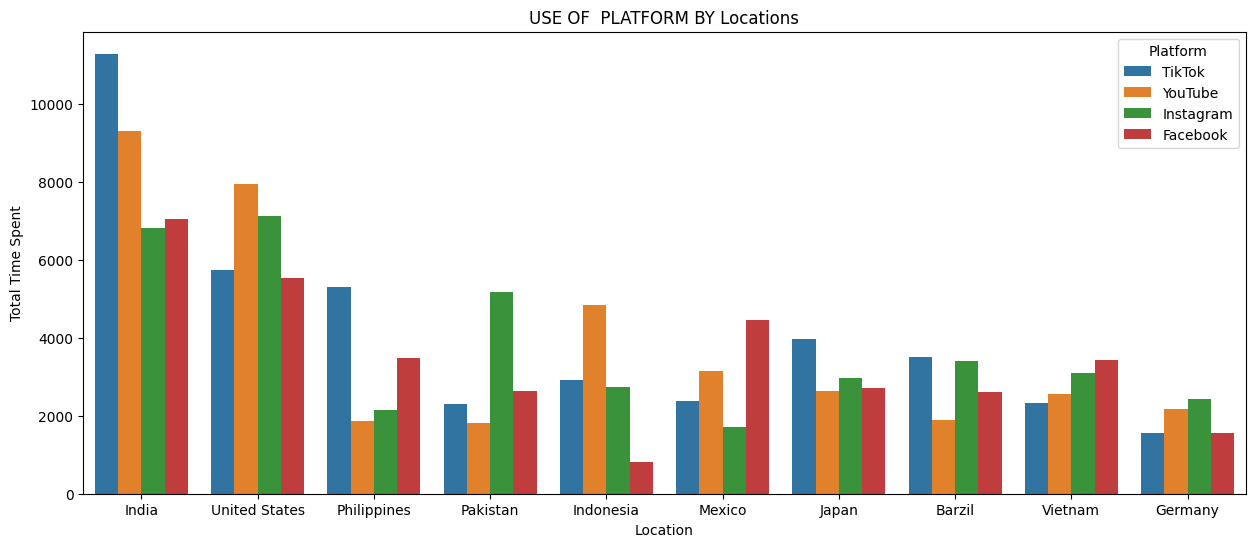

In [140]:
plt.figure(figsize=(15, 6))
sns.barplot(x='Location',y='Total Time Spent',hue='Platform',data = df_platform_by_location)
plt.title('USE OF  PLATFORM BY Locations')
plt.show()

# Average Addiction Level by Location

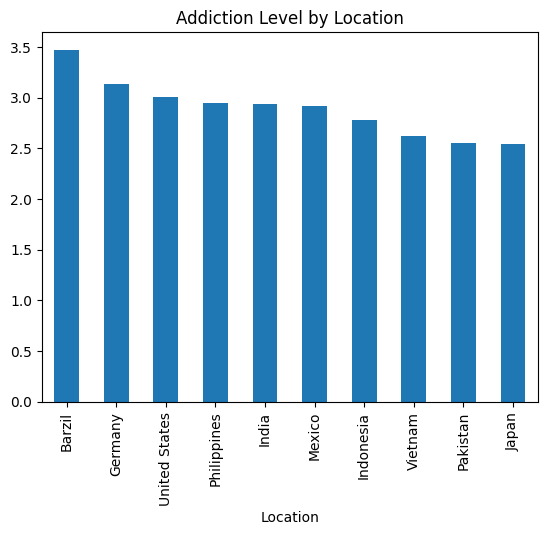

In [141]:
df_Addiction_level_loc = data.groupby('Location')['Addiction Level'].mean().sort_values(ascending = False).plot(kind='bar')
df_Addiction_level_loc.set_title('Addiction Level by Location')
plt.show()

In [142]:
data.Age.describe()

count    1000.000000
mean       40.986000
std        13.497852
min        18.000000
25%        29.000000
50%        42.000000
75%        52.000000
max        64.000000
Name: Age, dtype: float64

# Average Addiction level by Age Category

In [143]:
def age_category(age):
    if age < 18:
        return 'Teenager'
    elif age >= 18 and age < 30:
        return 'Young Adult'
    elif age >= 30 and age < 50:
        return 'Adult'
    else:
        return 'Senior'

In [144]:
data['Age Category'] = data['Age'].apply(age_category)


In [145]:
df_Add_by_age = data.groupby('Age Category')['Addiction Level'].mean().reset_index()
df_Add_by_age

,Age Category,Addiction Level
0,Adult,3.030516
1,Senior,2.868339
2,Young Adult,2.745098


Average addication level by Gender

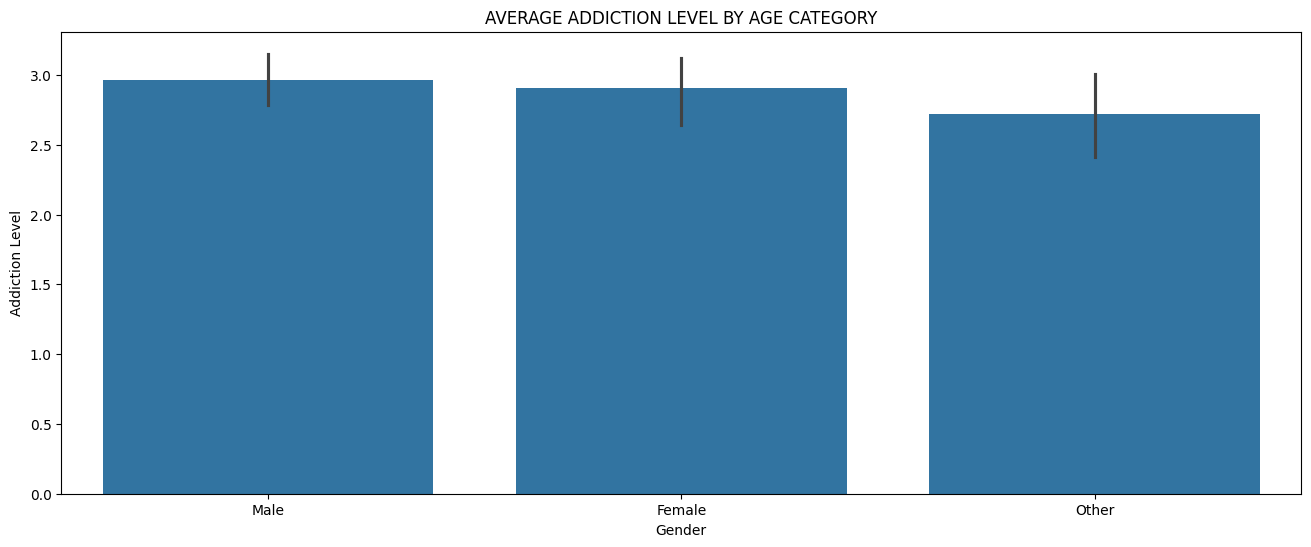

In [146]:
plt.figure(figsize=(16, 6))
sns.barplot(x='Gender',y='Addiction Level',data=data)
plt.title('AVERAGE ADDICTION LEVEL BY AGE CATEGORY')
plt.show()

In [147]:
data.Gender.value_counts().reset_index()

,Gender,count
0,Male,514
1,Female,322
2,Other,164


In [148]:
data.Income.describe()

count     1000.000000
mean     59524.213000
std      23736.212925
min      20138.000000
25%      38675.250000
50%      58805.000000
75%      79792.250000
max      99676.000000
Name: Income, dtype: float64

In [149]:
def income_category(income):
    if income < 50000:
        return 'Low'
    elif income >= 50000 and income < 100000:
        return 'Medium'
    else:
        return 'High'
data['Income Category'] = data['Income'].apply(income_category)
df_Add_by_income = data.groupby('Income Category')['Addiction Level'].mean().reset_index()
df_Add_by_income


,Income Category,Addiction Level
0,Low,3.037406
1,Medium,2.818030


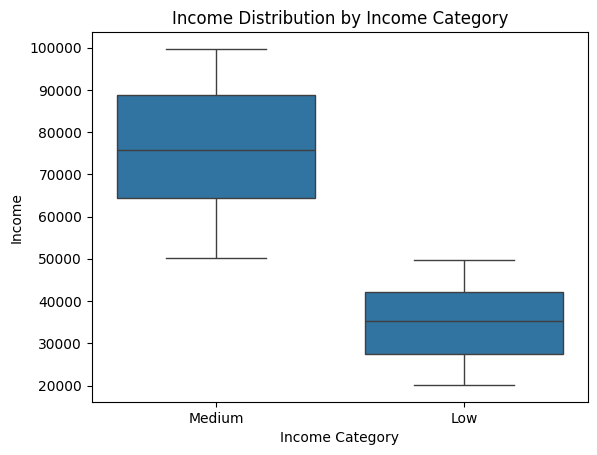

In [150]:
income_boxplot = sns.boxplot(x='Income Category', y='Income', data=data)
income_boxplot.set_title('Income Distribution by Income Category')
plt.show()

In [151]:
data.Profession.value_counts().reset_index()

,Profession,count
0,Students,246
1,Waiting staff,194
2,Labor/Worker,186
3,driver,113
4,Engineer,65
5,Cashier,56
6,Manager,54
7,Artist,47
8,Teacher,39


# Total Time spent an platform by Profession

In [152]:
df_Pro_Pla = data.groupby(['Profession' , 'Platform'])['Total Time Spent'].sum().sort_values(ascending = False).reset_index()
df_Pro_Pla.head(10)

,Profession,Platform,Total Time Spent
0,Students,Instagram,9983
1,Students,YouTube,9634
2,Students,TikTok,8936
3,Labor/Worker,TikTok,8491
4,Labor/Worker,Instagram,8104
5,Students,Facebook,8086
6,Waiting staff,Facebook,7882
7,Waiting staff,TikTok,7453
8,Waiting staff,Instagram,6962
9,Labor/Worker,YouTube,6737


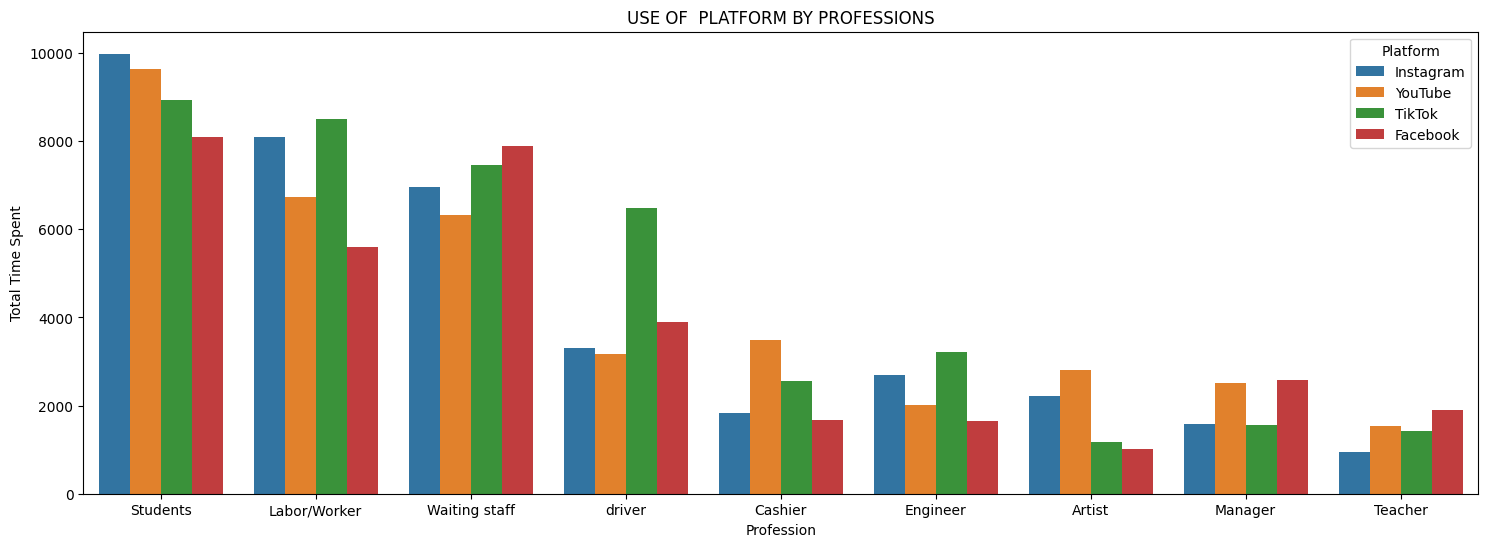

In [153]:
plt.figure(figsize=(18, 6))
sns.barplot(x='Profession',y='Total Time Spent',hue='Platform',data=df_Pro_Pla)
plt.title('USE OF  PLATFORM BY PROFESSIONS')
plt.show()

In [154]:
df_avg_time_engagement = data.groupby(['Profession', 'Watch Reason'])[['Time Spent On Video', 'Engagement']].mean().reset_index()
print(df_avg_time_engagement)

       Profession     Watch Reason  Time Spent On Video   Engagement
0          Artist          Boredom            21.454545  4824.636364
1          Artist    Entertainment            15.909091  4887.363636
2          Artist            Habit            15.150000  5127.700000
3          Artist  Procrastination            17.600000  2827.000000
4         Cashier          Boredom            15.894737  5891.000000
5         Cashier    Entertainment            15.375000  4805.687500
6         Cashier            Habit            16.684211  5079.000000
7         Cashier  Procrastination            14.000000  6766.000000
8        Engineer          Boredom            14.944444  4190.055556
9        Engineer    Entertainment            14.550000  4982.600000
10       Engineer            Habit            19.222222  4053.388889
11       Engineer  Procrastination            13.888889  5032.888889
12   Labor/Worker          Boredom            14.545455  5215.045455
13   Labor/Worker    Entertainment

In [155]:
data.Engagement.describe()

count    1000.000000
mean     4997.159000
std      2910.053701
min        15.000000
25%      2415.750000
50%      5016.000000
75%      7540.250000
max      9982.000000
Name: Engagement, dtype: float64

# Watch Time of day when user watches videos

C:\Users\CC-Student\AppData\Local\Temp\ipykernel_7592\2168416543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data['Watch Time'].values, y=data['Watch Time'].index, data=data, palette='viridis')


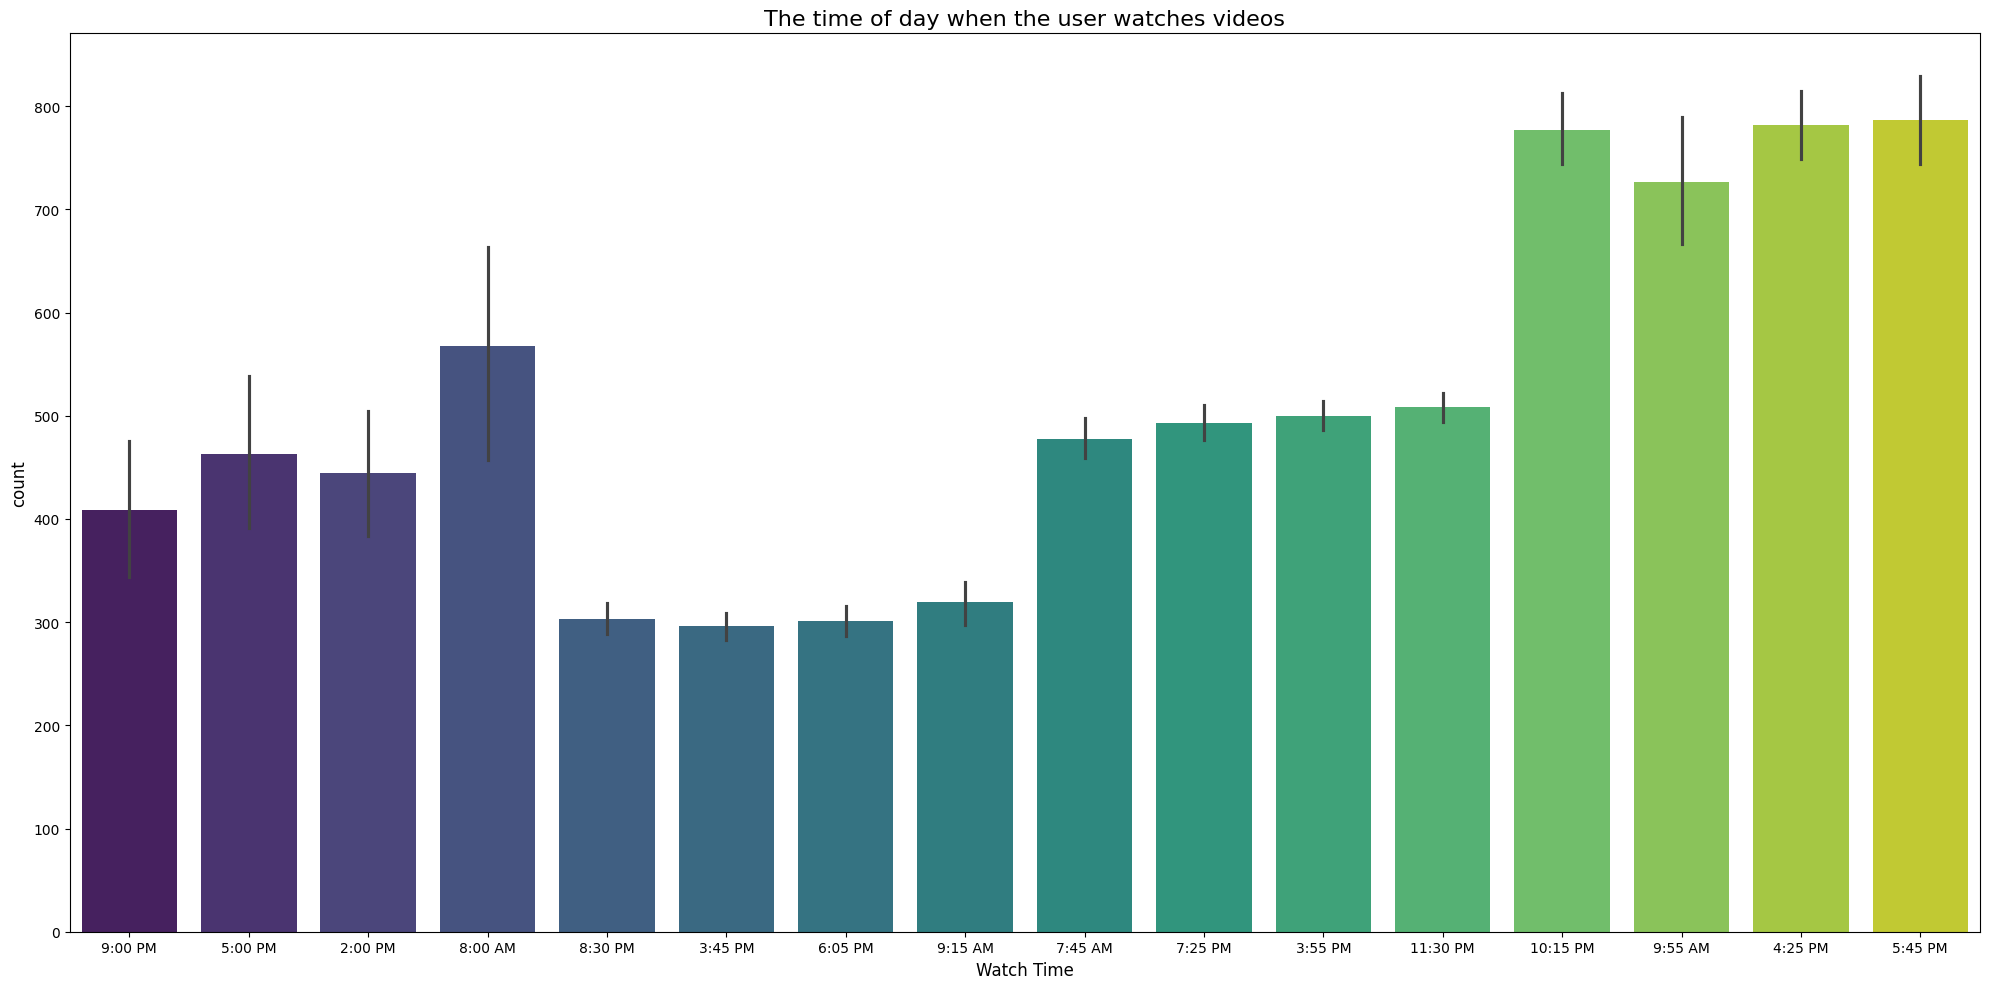

In [156]:
 plt.figure(figsize=(20, 10))
 sns.barplot(x=data['Watch Time'].values, y=data['Watch Time'].index, data=data, palette='viridis')
 plt.title('The time of day when the user watches videos', fontsize=16)
 plt.xlabel('Watch Time', fontsize=12)
 plt.ylabel('count', fontsize=12)
 plt.tight_layout()
 plt.show()

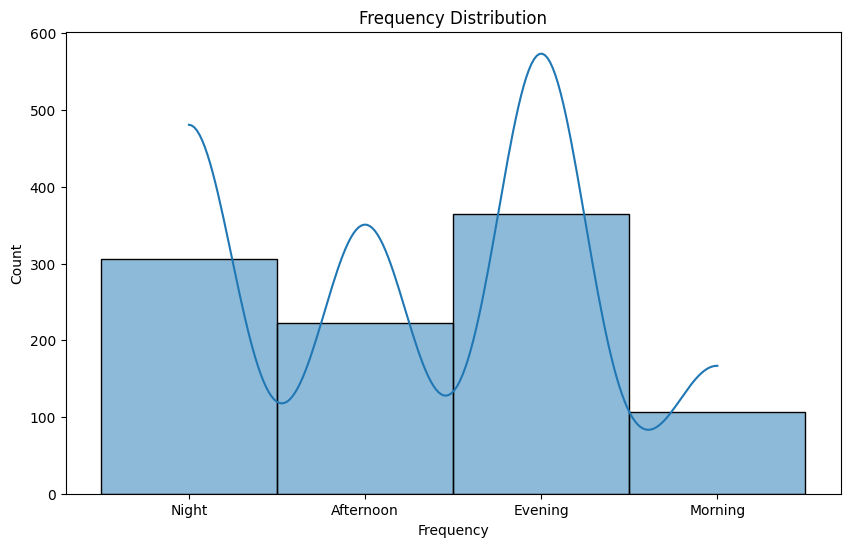

In [157]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.show()

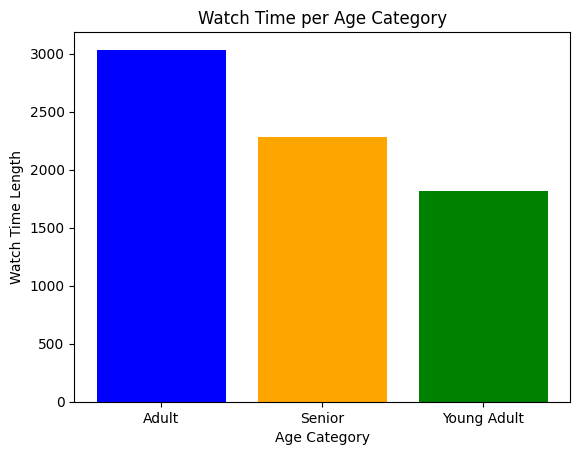

In [158]:
# Convert 'Watch Time' to the length of the string
watch_time_by_age['Watch Time Length'] = watch_time_by_age['Watch Time'].apply(len)

# Plot the data
plt.bar(watch_time_by_age['Age Category'], watch_time_by_age['Watch Time Length'], color=['blue', 'orange', 'green'])

plt.title("Watch Time per Age Category")
plt.xlabel("Age Category")
plt.ylabel("Watch Time Length")
plt.show()

In [159]:
average_income = data.groupby('Location')['Income'].mean().reset_index()
average_income.columns = ['Location', 'Average Income']
print(average_income)

        Location  Average Income
0         Barzil    55662.076923
1        Germany    60478.118644
2          India    58865.421053
3      Indonesia    60864.155844
4          Japan    61745.480000
5         Mexico    61783.630137
6       Pakistan    56225.000000
7    Philippines    58688.628205
8  United States    60245.954023
9        Vietnam    61363.182927


In [160]:
df_time_spend_on_video = data.groupby('Video Category')['Time Spent On Video'].sum().sort_values(ascending = False).reset_index()
df_time_spend_on_video

,Video Category,Time Spent On Video
0,Jokes/Memes,2638
1,Life Hacks,2397
2,Pranks,1804
3,Vlogs,1800
4,Gaming,1719
5,Entertainment,1547
6,Trends,1420
7,ASMR,1135
8,Comedy,513


# Time Spent on Video Category

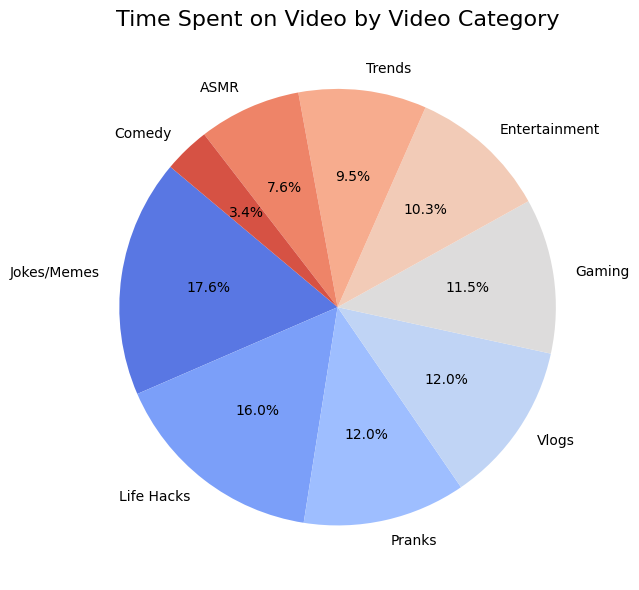

In [161]:
plt.figure(figsize=(30, 6))
plt.pie(df_time_spend_on_video['Time Spent On Video'], labels=df_time_spend_on_video['Video Category'], 
        autopct='%1.1f%%', colors=sns.color_palette('coolwarm', len(df_time_spend_on_video)), startangle=140)
plt.title('Time Spent on Video by Video Category', fontsize=16)
plt.tight_layout()
plt.show()

# Time spent on videos of platform by video category

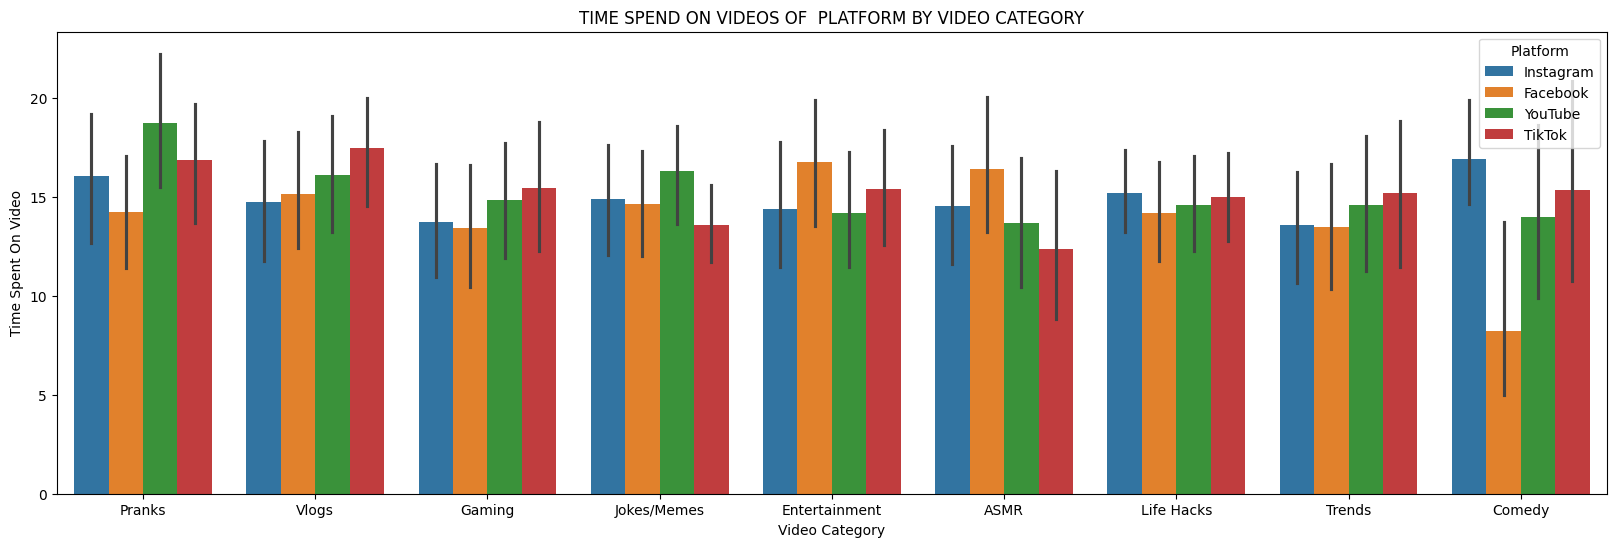

In [162]:
plt.figure(figsize=(20, 6))
sns.barplot(x='Video Category',y='Time Spent On Video',hue='Platform',data=data)
plt.title('TIME SPEND ON VIDEOS OF  PLATFORM BY VIDEO CATEGORY')
plt.show()

# Time spent on videos by Age category and videos category

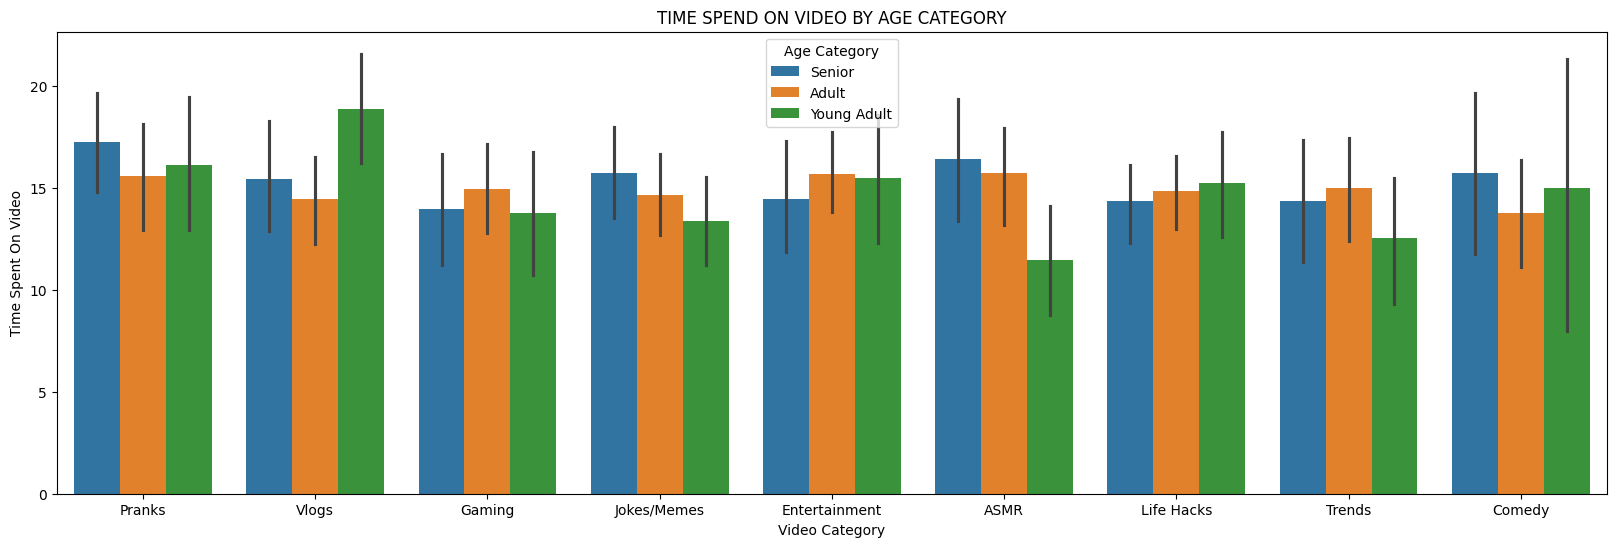

In [163]:
plt.figure(figsize=(20, 6))
sns.barplot(x='Video Category', y='Time Spent On Video', hue='Age Category', data=data)
plt.title('TIME SPEND ON VIDEO BY AGE CATEGORY')
plt.show()

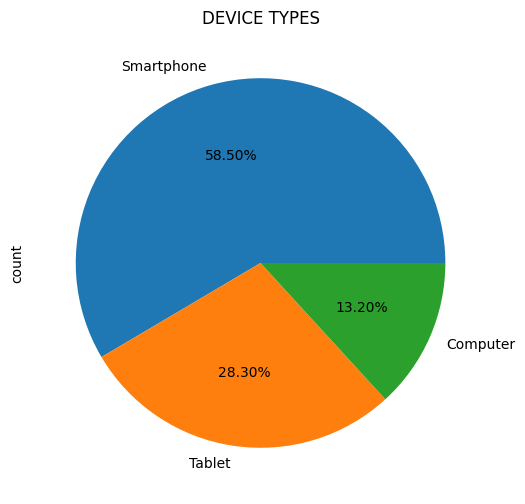

In [164]:
plt.figure(figsize=(15, 6))
data['DeviceType'].value_counts().plot(kind='pie',title='DEVICE TYPES',autopct="%1.2f%%")
plt.show()

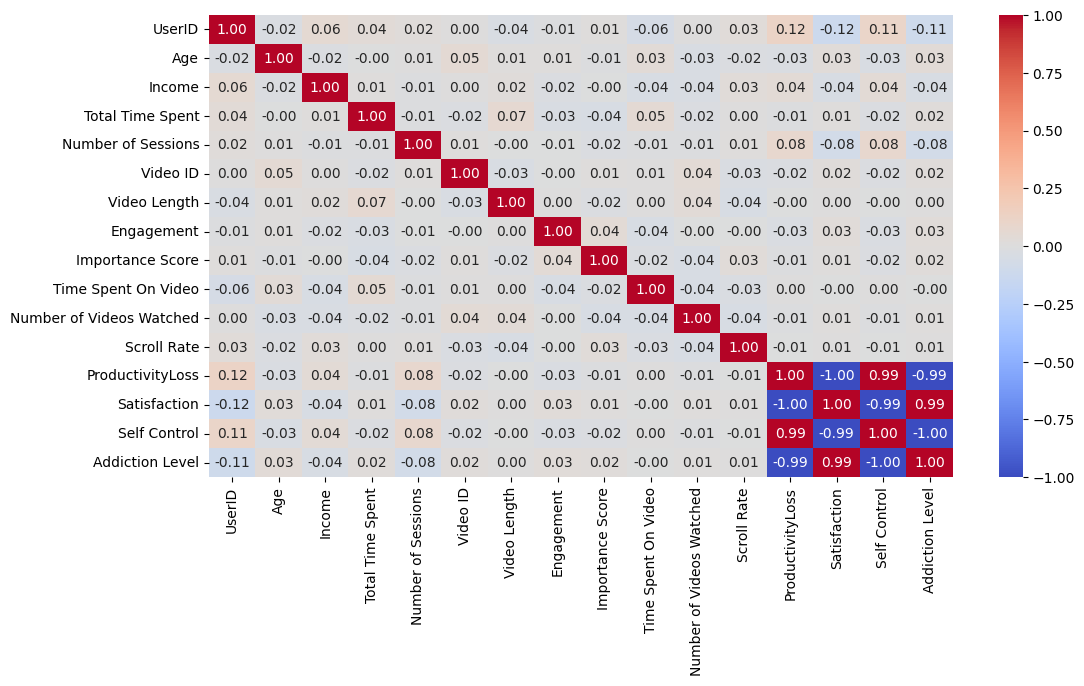

In [165]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 6))
sns.heatmap(data[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

# Titel und Anzeige
plt.show()

In [166]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

data.head()

,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,...,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType,Age Category,Income Category
0,1,56,1,6,82812,True,True,2,0,1,...,3,1,0,13,5,5,3,0,1,1
1,2,46,0,5,27999,False,True,0,1,1,...,2,0,0,6,7,3,1,1,0,0
2,3,32,0,8,42436,False,True,2,0,0,...,1,2,0,2,8,2,0,0,0,0
3,4,60,1,0,62963,True,False,7,0,3,...,2,1,0,13,5,5,3,0,1,1
4,5,25,1,6,22096,False,True,4,1,2,...,0,1,3,11,10,0,0,0,2,0


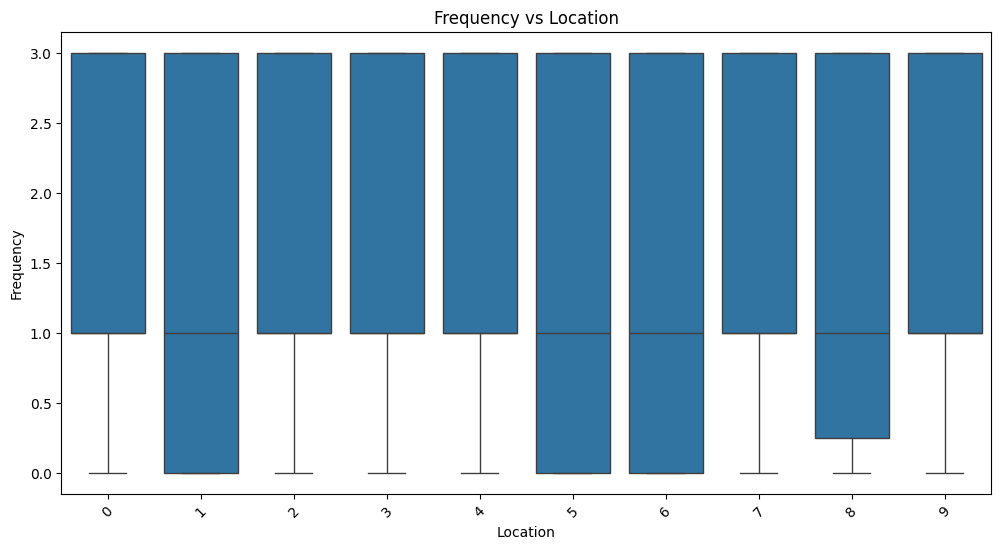

In [167]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Location', y='Frequency', data=data)
plt.title('Frequency vs Location')
plt.xlabel('Location')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

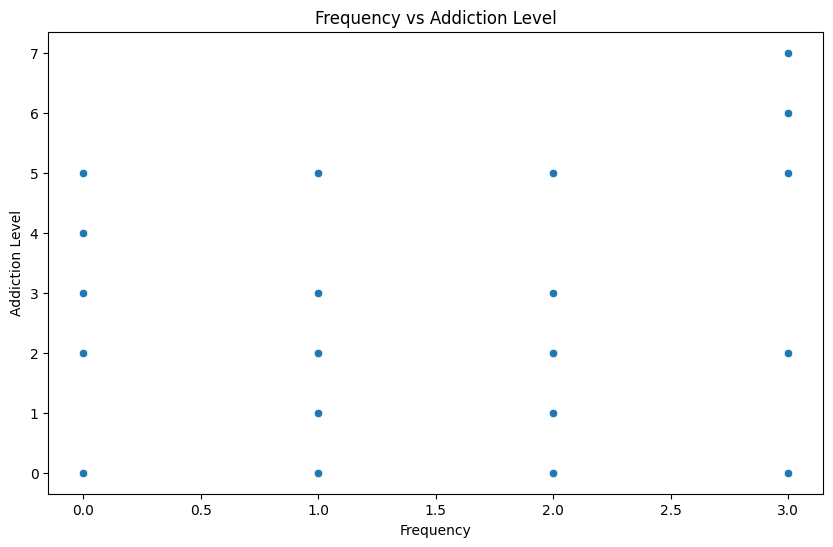

In [168]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Frequency', y='Addiction Level', data=data)
plt.title('Frequency vs Addiction Level')
plt.xlabel('Frequency')
plt.ylabel('Addiction Level')
plt.show()